In [3]:
%matplotlib inline
import jax.numpy as jnp
import matplotlib.pyplot as plt

import sys
sys.path.insert(0, "../")  
from TOOL_BOX_OF_FUNCTIONS.GAUSSIAN_POSTERIOR_FUNCTION import POSTERIOR as POST 
from TOOL_BOX_OF_FUNCTIONS.BAYESIAN_REGRESSION import BAYES_REG as BR 

def print_shape(obj, name=""):
    """Prints the shape of an object if it has one."""
    try:
        shape = obj.shape
        if name:
            print(f"{name}.shape = {shape}")
        else:
            print(f"Shape: {shape}")
    except AttributeError:
        print(f"Object {name or ''} has no attribute 'shape'")


#### Conjugate Linear Regression (posterior, predictive, evidence)

You observe
$$
X = \begin{bmatrix}
1 & 0 \\
1 & 1 \\
1 & 2
\end{bmatrix}, \quad
y = \begin{bmatrix}
0.2 \\
1.1 \\
1.9
\end{bmatrix}.
$$

Model:
$$
y \mid w \sim \mathcal{N}(Xw, \sigma^2 I), \quad \text{prior } w \sim \mathcal{N}(0, \alpha^{-1} I_2).
$$
Use: $\sigma^2 = 0.10$, $\alpha = 4$.

1) Derive $p(w \mid y, X)$ and compute its mean and covariance.

2) Compute $p(y^* \mid x^*, y, X)$ at $x^* = \begin{bmatrix}1 \\ 1\end{bmatrix}$.

3) Compute $\log p(y \mid X, \sigma^2, \alpha)$ (the evidence).

4) Compute $w_{\text{ML}}$ and $w_{\text{MAP}}$; interpret the shrinkage.
5) Determine the analytical distribution $p(y| w, X, \sigma^2)$



### 1) 
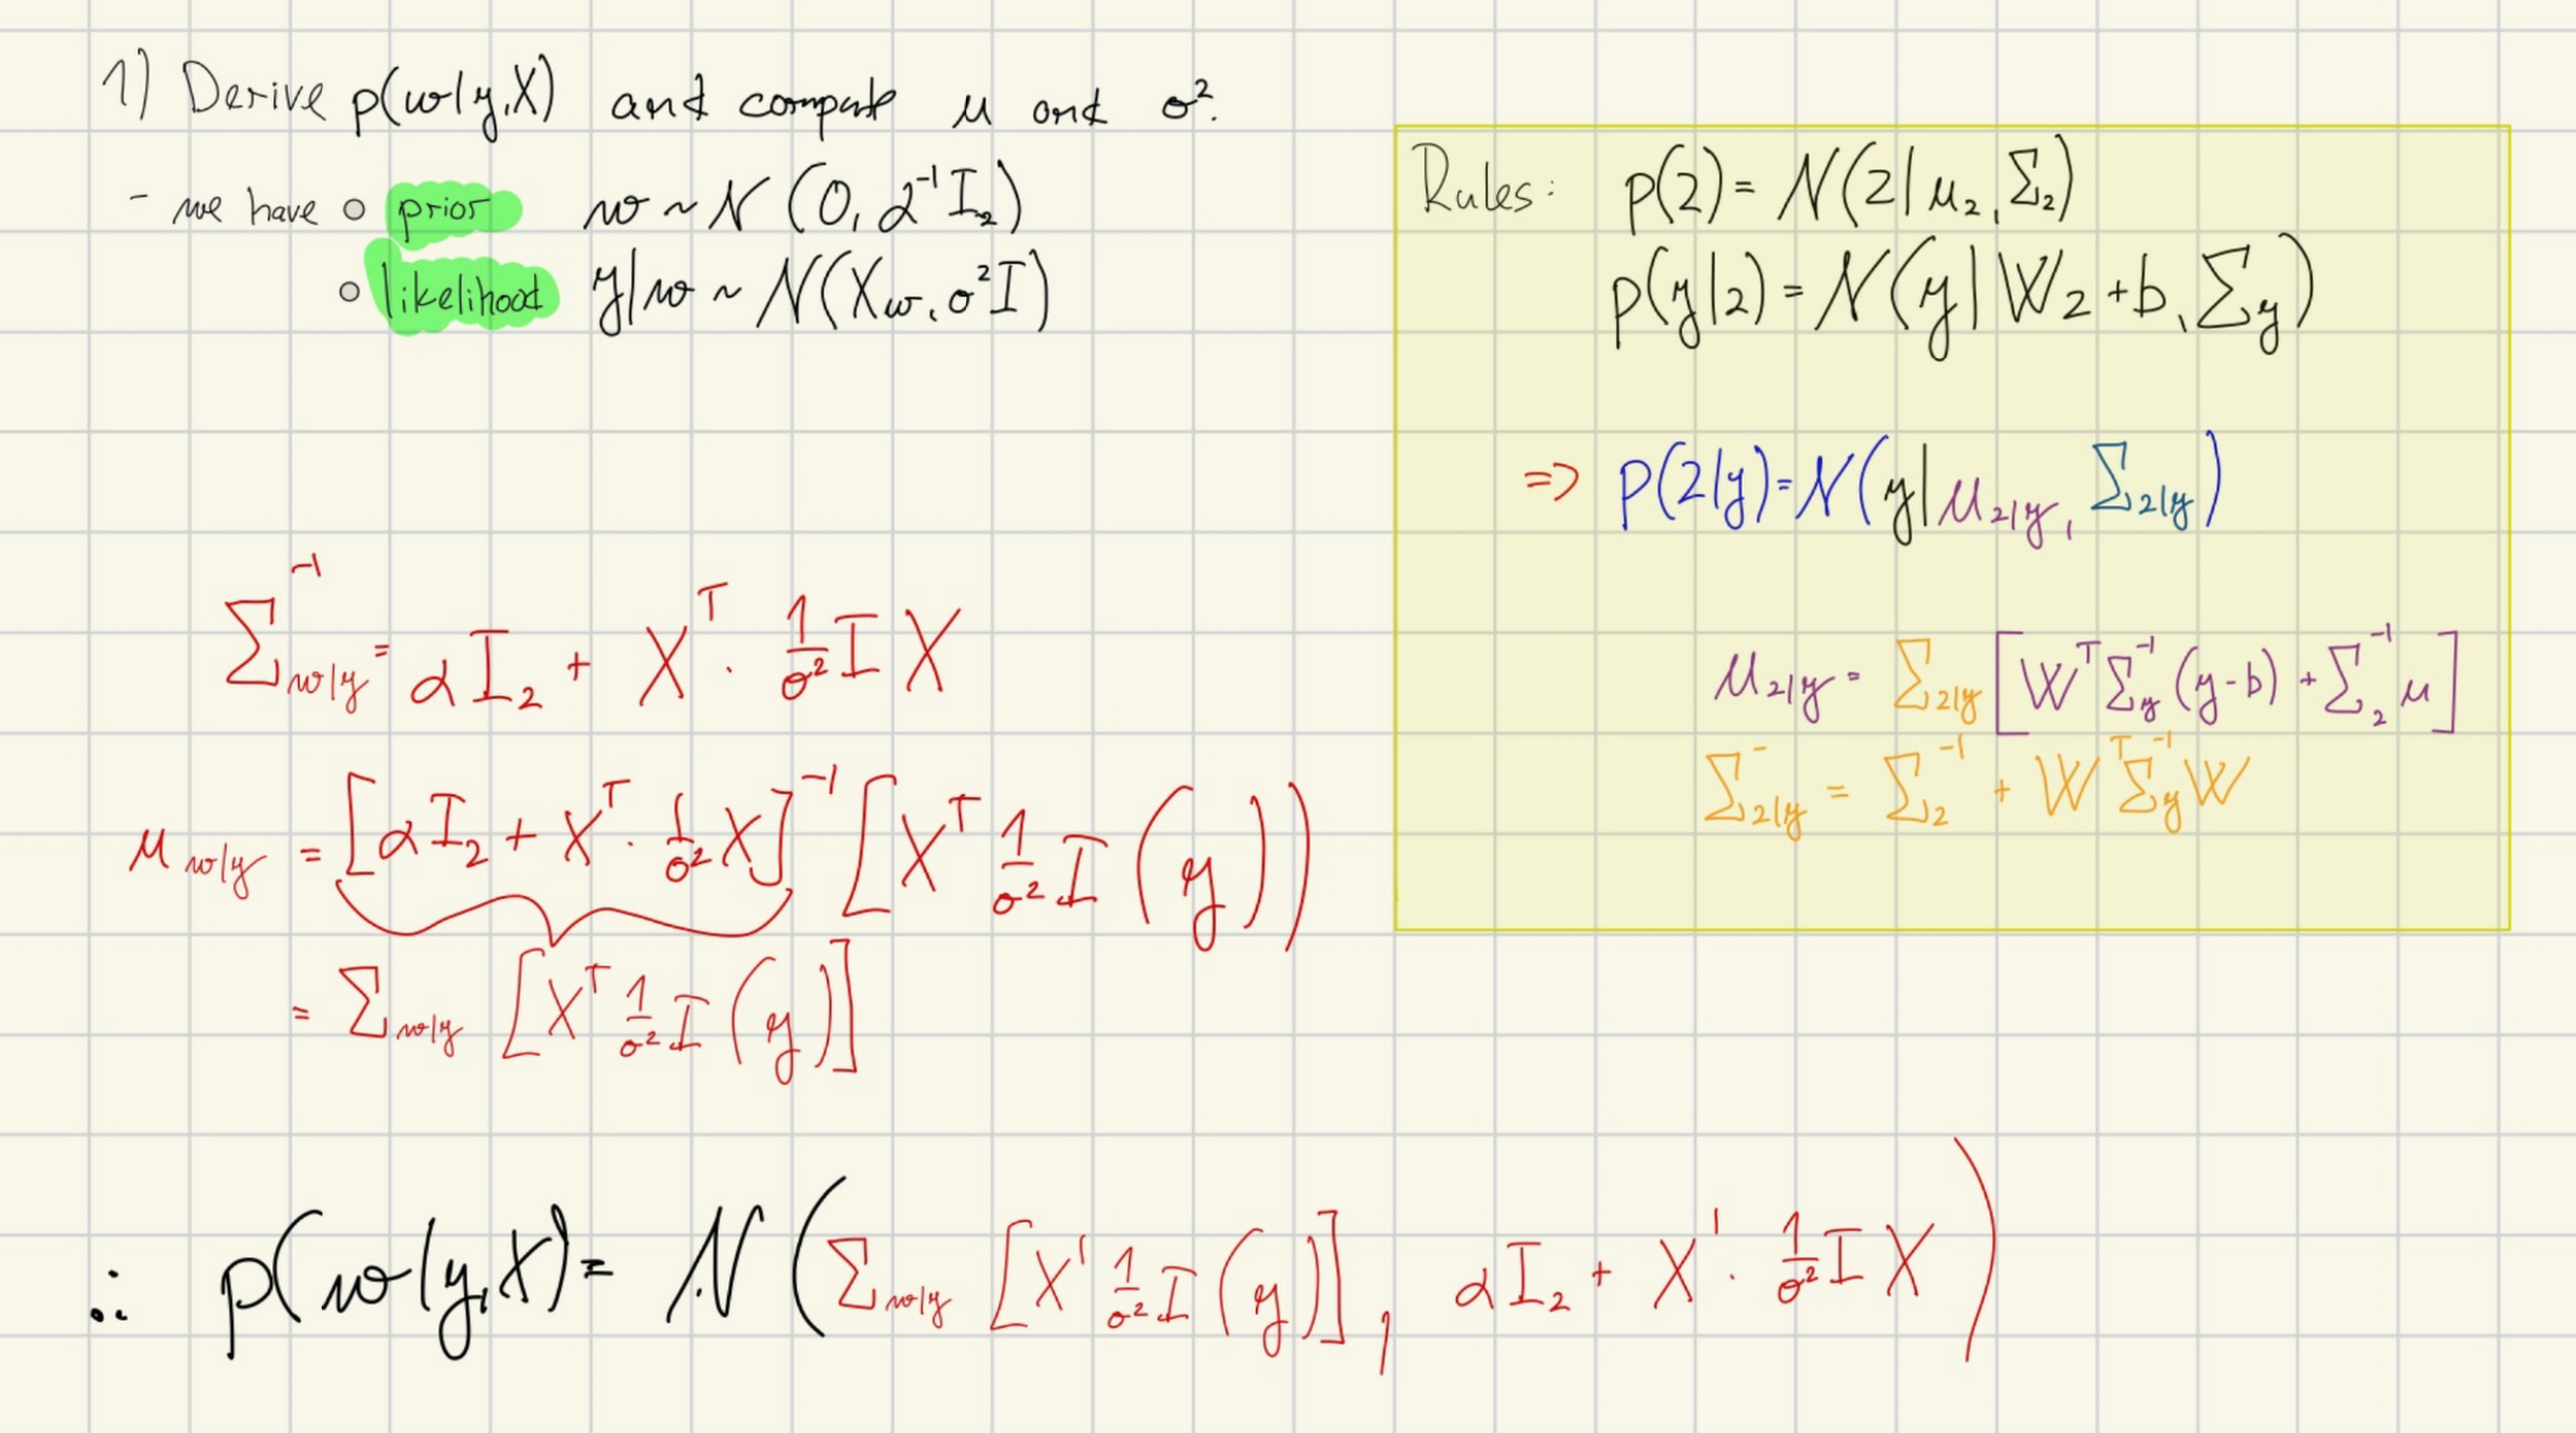

In [4]:
X = jnp.array([
    [1, 0], 
    [1, 1],
    [1, 2]
]) # shape (3, 2)

y = jnp.array([
    0.2, 
    1.1,
    1.9
]).reshape(-1, 1) # shape (3,1)

sigma_2 = 0.10 
alpha   = 4

It is best idea to precompute the matrices. 

# In Hand ish

**Compute $X^T X$**

In [5]:
# X^T X 
XtX = X.T @ X # shape (2, 3) x (3, 2) => shape (2, 2)
print(f"X^T @ X = \n{XtX}")
print(f"X^T @ X = {XtX.shape}")

X^T @ X = 
[[3 3]
 [3 5]]
X^T @ X = (2, 2)


Compute $X^T y$

In [6]:
Xty = X.T @ y # shape (2, 1)
print(f"X^T @ y = \n{Xty}")
print(f"X^T @ y = {Xty.shape}")

X^T @ y = 
[[3.2]
 [4.9]]
X^T @ y = (2, 1)


Copute posteror precition matrix $A$

$$A = \alpha I + \dfrac{1}{\sigma^2} X^T X

In [7]:
I = jnp.eye(X.shape[1]) # identiy matrix of shape (2, 2)
A = alpha * I + (1 / sigma_2) * XtX # shape: (2, 2)

Invert A to get posterior covariance $\Sigma$

In [8]:
Sigma = jnp.linalg.inv(A)

 Compute posterior mean $mu = \left(\dfrac{1}{\sigma^2} X^T y \right)$

In [9]:
mu = Sigma @ ((1 / sigma_2) * Xty)
mu

Array([[0.27564108],
       [0.75427353]], dtype=float32)

In [10]:
Sigma 

Array([[ 0.05769231, -0.03205128],
       [-0.03205128,  0.03632479]], dtype=float32)

# Function 

In [11]:
mu_f, Sigma_f = POST.bayesian_linear_regression_posterior(X=X, y=y, alpha=alpha, sigma2=sigma_2)

In [12]:
print(mu_f)

[[0.27564108]
 [0.75427353]]


In [13]:
print(Sigma_f)

[[ 0.05769231 -0.03205128]
 [-0.03205128  0.03632479]]


# Teachers class

In [14]:
model = BR.BayesianLinearRegression(Phi=X, y=y, alpha=alpha, beta=sigma_2)

In [15]:
m_B, S_B = model.compute_posterior(alpha=alpha, beta=1/sigma_2)


In [16]:
m_B

Array([[0.27564114],
       [0.75427353]], dtype=float32)

In [17]:
S_B

Array([[ 0.05769231, -0.03205128],
       [-0.03205128,  0.03632479]], dtype=float32)

### 2) 

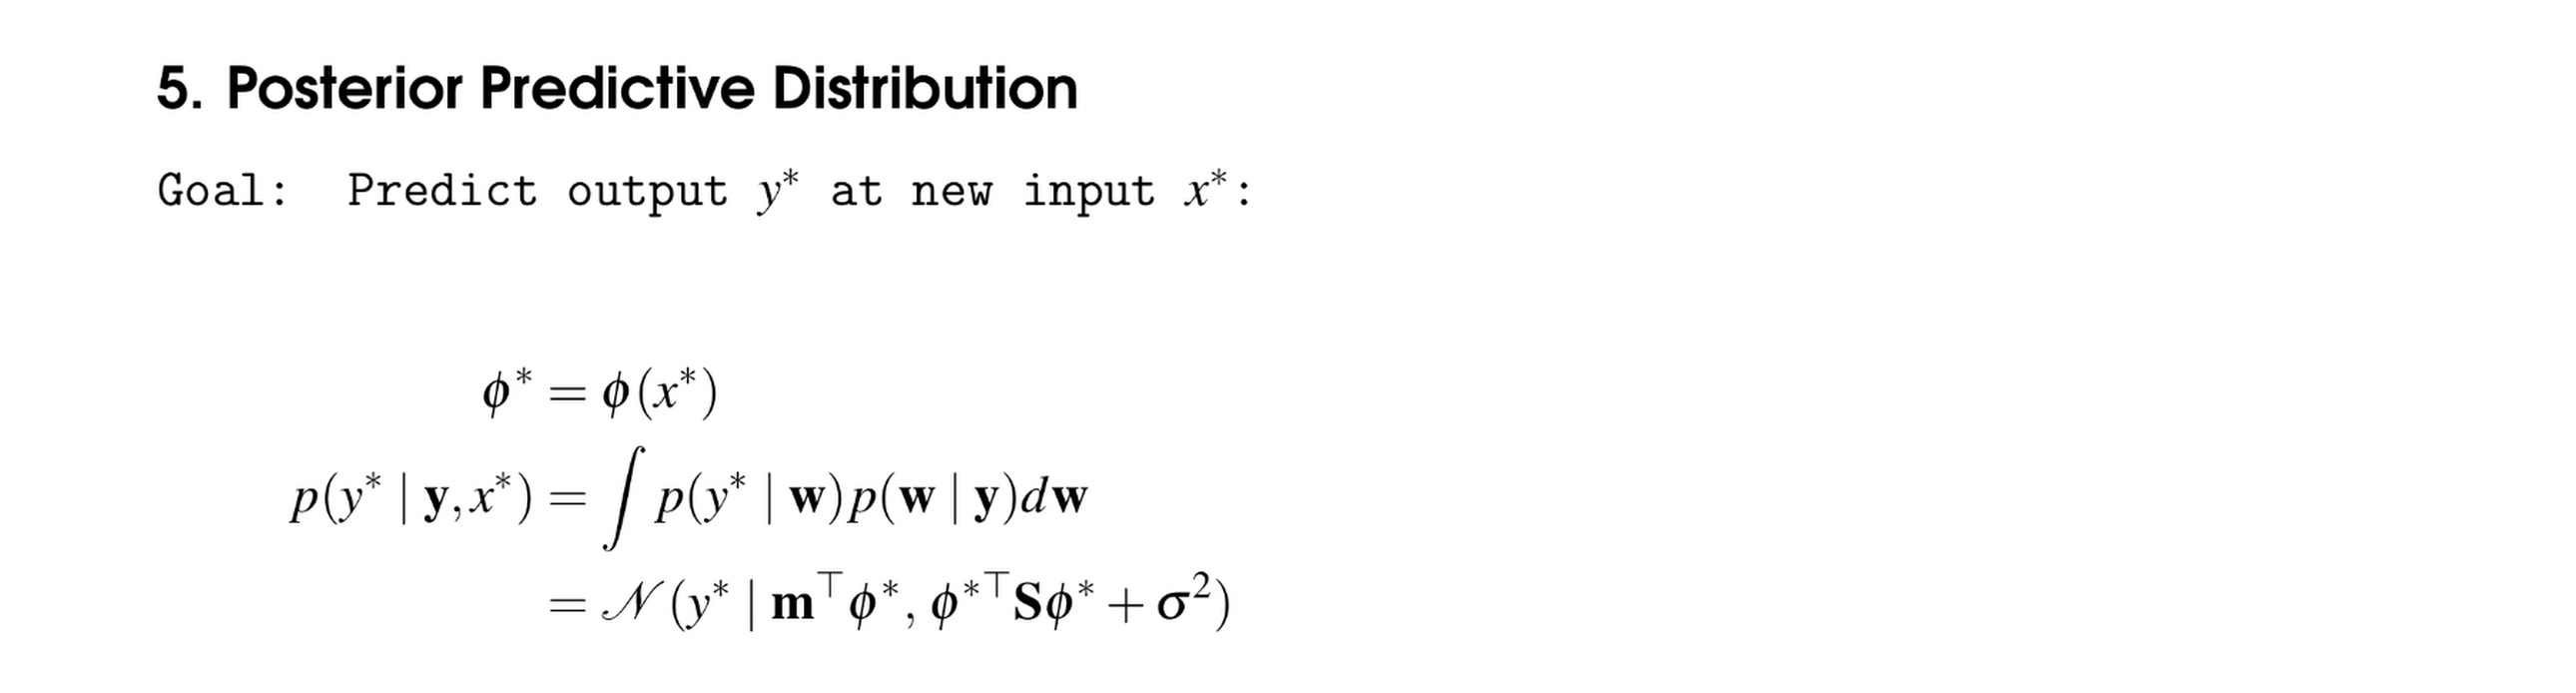

In [18]:
x_star = jnp.array([[1], [1]]).reshape(-1 , 1)
print(x_star)
print_shape(x_star)


[[1]
 [1]]
Shape: (2, 1)


In [19]:
MUt_x_star = mu_f.T @ x_star

print(MUt_x_star)
print_shape(MUt_x_star)

[[1.0299146]]
Shape: (1, 1)


In [20]:
S_star = x_star.T @ Sigma @ x_star + sigma_2

In [21]:
print(S_star)
print_shape(S_star)

[[0.12991454]]
Shape: (1, 1)


In [22]:
m_B, S_B = model.predict_y(x_star.T)

In [23]:
m_B

Array([0.17154723], dtype=float32)

In [24]:
S_B

Array([10.425753], dtype=float32)

### 3) 

In [25]:
evidence = model.log_marginal_likelihood

print(f"log({evidence})")

log(-6.510091304779053)


In [26]:
def log_evidence(X, sigma2, alpha):
    N = X.shape[0]
    Sigma_y = sigma2 * jnp.eye(N) + (1 / alpha) * X @ X.T 
    logdet = jnp.linalg.slogdet(Sigma_y)[1]
    inv_Sigma_y = jnp.linalg.inv(Sigma_y)
    
    log_ev = -0.5 * N * jnp.log(2 * jnp.pi ) - 0.5 * logdet - 0.5 * y.T @ inv_Sigma_y @ y 
    
    return log_ev

evidence_fun = log_evidence(X, sigma2=sigma_2, alpha=alpha)
evidence_fun

Array([[-2.7474942]], dtype=float32)

In [27]:
from scipy.stats import multivariate_normal
def log_probability_scipy(y, X, sigma, alpha):
    # Calculate the covariance matrix
    covariance = sigma**2 * jnp.eye(X.shape[0]) + (1 / alpha) * X @ X.T

    # Create a multivariate normal distribution with mean 0 and the calculated covariance
    mvn = multivariate_normal(mean=jnp.zeros_like(y), cov=covariance)

    # Calculate the log probability
    log_prob = mvn.logpdf(y)

    return log_prob

In [28]:
evidence_scipy = log_probability_scipy(y=jnp.array([
    0.2, 
    1.1,
    1.9
]), X=X, sigma=sigma_2, alpha=alpha)

### 4) 

In [ ]:
w_MLE = model.get_w_mle()
print(w_MLE)

[[0.21666679]
 [0.84999996]]


In [32]:
w_ML_in_hand = jnp.linalg.inv(X.T @ X) @ X.T @ y 
print(w_ML_in_hand)

[[0.21666679]
 [0.84999996]]


### 5) 

In [37]:
import jax.numpy as jnp
from jax.scipy.stats import multivariate_normal

def log_likelihood(y, Phi, w, sigma2):
    """
    Computes log p(y | w, Phi, sigma^2), the log-likelihood.

    Parameters:
        y : (N, 1) or (N,)
        Phi : (N, D) design matrix
        w : (D, 1) or (D,)
        sigma2 : scalar noise variance

    Returns:
        log_lik : scalar, log-likelihood
    """
    y = y.reshape(-1, 1)  # (N, 1)
    w = w.reshape(-1, 1)  # (D, 1)
    N = y.shape[0]

    residual = y - Phi @ w  # (N, 1)
    mse = (residual.T @ residual).squeeze()  # scalar

    log_normalizer = -0.5 * N * jnp.log(2 * jnp.pi * sigma2)
    log_exp = -0.5 * mse / sigma2

    return log_normalizer + log_exp


In [38]:
def likelihood(y, Phi, w, sigma2):
    return jnp.exp(log_likelihood(y, Phi, w, sigma2))


In [39]:
likelihood_ = likelihood(y=y, Phi=X, sigma2=sigma_2, w=jnp.array([0, 1]))

likelihood_